In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')
print(fg.head())
print(hd.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

/tmp/ipykernel_23890/3482431045.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  hd = pd.read_csv('historical_data.csv')


In [3]:
print(fg.shape, hd.shape)
print(fg.dtypes)
print(hd.dtypes)

(2644, 4) (172624, 16)
timestamp          int64
value              int64
classification    object
date              object
dtype: object
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed              object
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [4]:
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

In [5]:
print(fg.shape)
print(hd.shape)
print(fg.head())
print(hd.head())

(2644, 4)
(211224, 16)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63 

In [7]:
#Parse Data
fg['date'] = pd.to_datetime(fg['date'])
hd['date'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True, errors='coerce').dt.normalize()

In [9]:
df = hd.merge(fg[['date', 'value', 'classification']], on='date', how='inner')

print(df.shape)
print(df.head())

(211218, 19)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

In [10]:
# Clean up columns
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce').fillna(0)
df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce').fillna(0)

# Helper columns
df['is_close'] = df['Direction'].isin(['Close Long', 'Close Short'])
df['is_profit'] = df['Closed PnL'] > 0

# Filter only closing trades (these are the ones with actual PnL)
closed = df[df['is_close']]

print(f"Total trades: {len(df):,}")
print(f"Closed trades: {len(closed):,}")
print(f"Sentiment breakdown:\n{df['classification'].value_counts()}")

Total trades: 211,218
Closed trades: 84,685
Sentiment breakdown:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [11]:
sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Avg PnL per sentiment
avg_pnl = closed.groupby('classification')['Closed PnL'].mean().reindex(sent_order)

# Win rate per sentiment
win_rate = closed.groupby('classification')['is_profit'].mean().reindex(sent_order) * 100

# Total PnL per sentiment
total_pnl = closed.groupby('classification')['Closed PnL'].sum().reindex(sent_order)

print("Avg PnL by Sentiment:")
print(avg_pnl)
print("\nWin Rate by Sentiment:")
print(win_rate)
print("\nTotal PnL by Sentiment:")
print(total_pnl)

Avg PnL by Sentiment:
classification
Extreme Fear      95.254470
Fear             126.413972
Neutral           68.317023
Greed             69.172563
Extreme Greed     46.227967
Name: Closed PnL, dtype: float64

Win Rate by Sentiment:
classification
Extreme Fear     79.963667
Fear             88.591821
Neutral          83.001957
Greed            76.076605
Extreme Greed    87.385807
Name: is_profit, dtype: float64

Total PnL by Sentiment:
classification
Extreme Fear     8.913913e+05
Fear             3.347568e+06
Neutral          1.082347e+06
Greed            1.336414e+06
Extreme Greed    6.325373e+05
Name: Closed PnL, dtype: float64


/tmp/ipykernel_23890/3296955768.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(sent_order, rotation=15, ha='right')
/tmp/ipykernel_23890/3296955768.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sent_order, rotation=15, ha='right')
/tmp/ipykernel_23890/3296955768.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(sent_order, rotation=15, ha='right')


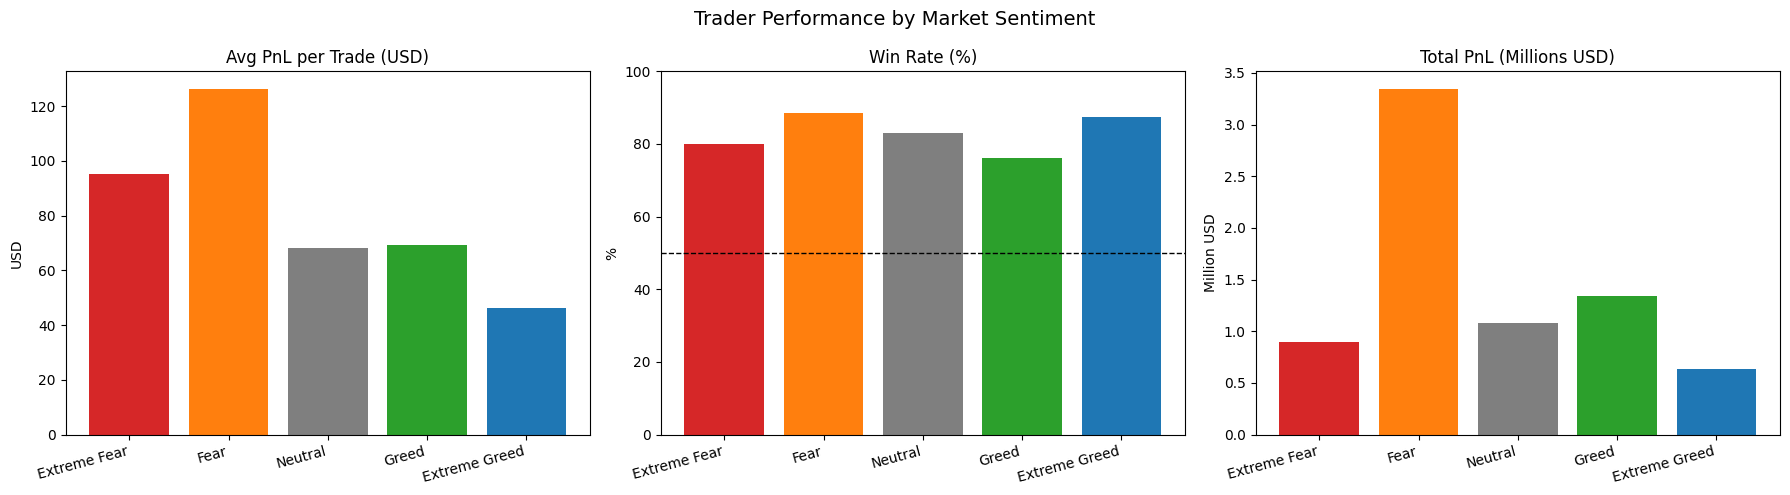

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=14)

# Avg PnL
axes[0].bar(sent_order, avg_pnl, color=['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#1f77b4'])
axes[0].set_title('Avg PnL per Trade (USD)')
axes[0].set_xticklabels(sent_order, rotation=15, ha='right')
axes[0].set_ylabel('USD')

# Win Rate
axes[1].bar(sent_order, win_rate, color=['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#1f77b4'])
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Win Rate (%)')
axes[1].set_xticklabels(sent_order, rotation=15, ha='right')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('%')

# Total PnL
axes[2].bar(sent_order, total_pnl/1e6, color=['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#1f77b4'])
axes[2].set_title('Total PnL (Millions USD)')
axes[2].set_xticklabels(sent_order, rotation=15, ha='right')
axes[2].set_ylabel('Million USD')

plt.tight_layout()
plt.show()

Long Avg PnL:
classification
Extreme Fear     81.197371
Fear             83.000111
Neutral          52.815787
Greed            88.958554
Extreme Greed    61.830783
Name: Closed PnL, dtype: float64

Short Avg PnL:
classification
Extreme Fear     123.400238
Fear             207.676658
Neutral           94.796313
Greed             55.195496
Extreme Greed     28.970490
Name: Closed PnL, dtype: float64


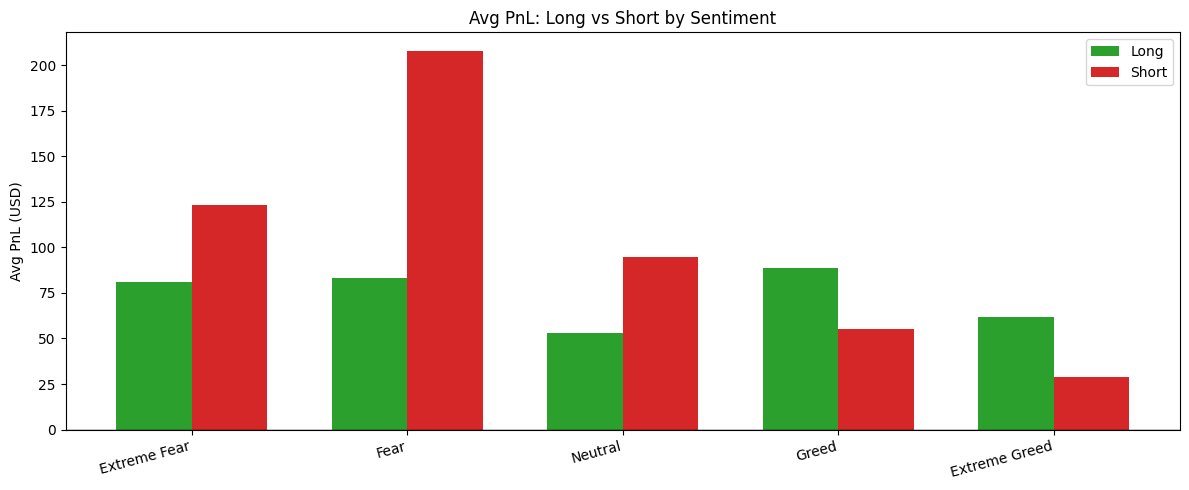

In [13]:
# Separate long and short closing trades
long_trades = df[df['Direction'] == 'Close Long']
short_trades = df[df['Direction'] == 'Close Short']

# Avg PnL for each
long_pnl = long_trades.groupby('classification')['Closed PnL'].mean().reindex(sent_order)
short_pnl = short_trades.groupby('classification')['Closed PnL'].mean().reindex(sent_order)

print("Long Avg PnL:")
print(long_pnl)
print("\nShort Avg PnL:")
print(short_pnl)

# Plot
x = np.arange(len(sent_order))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, long_pnl, w, label='Long', color='#2ca02c')
ax.bar(x + w/2, short_pnl, w, label='Short', color='#d62728')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Avg PnL: Long vs Short by Sentiment')
ax.set_xticks(x)
ax.set_xticklabels(sent_order, rotation=15, ha='right')
ax.set_ylabel('Avg PnL (USD)')
ax.legend()
plt.tight_layout()
plt.show()

Top 10 Coins by Total PnL:
Coin
HYPE       1.948062e+06
SOL        1.628228e+06
ETH        1.314432e+06
BTC        8.862948e+05
MELANIA    3.891310e+05
ENA        2.106171e+05
SUI        1.991583e+05
DOGE       1.475013e+05
ZRO        1.262993e+05
AIXBT      7.371217e+04
Name: Closed PnL, dtype: float64


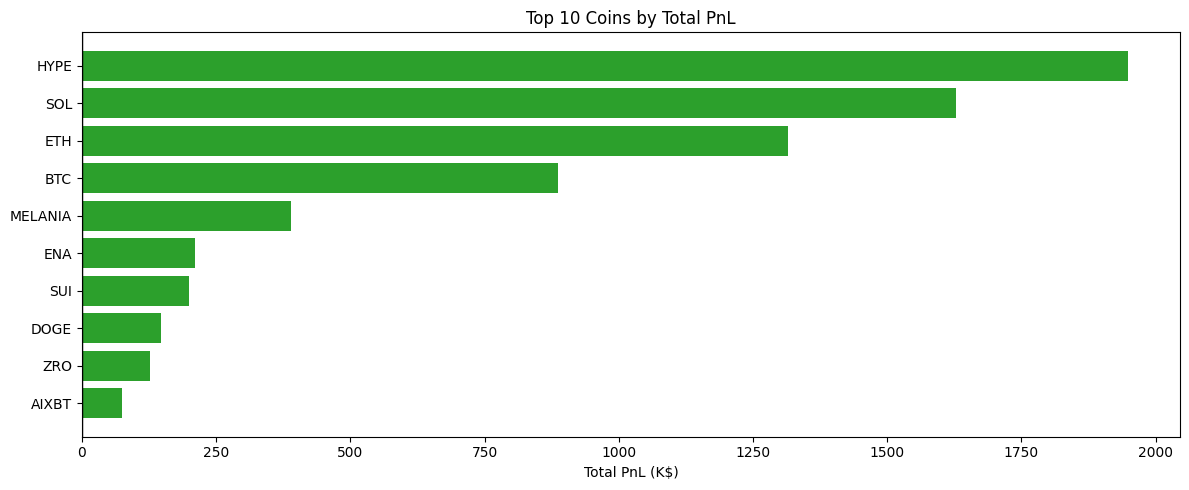

In [14]:
# Top 10 coins by total PnL
coin_pnl = closed.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print("Top 10 Coins by Total PnL:")
print(coin_pnl)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in coin_pnl]
ax.barh(coin_pnl.index[::-1], coin_pnl.values[::-1] / 1e3, color=colors[::-1])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 10 Coins by Total PnL')
ax.set_xlabel('Total PnL (K$)')
plt.tight_layout()
plt.show()

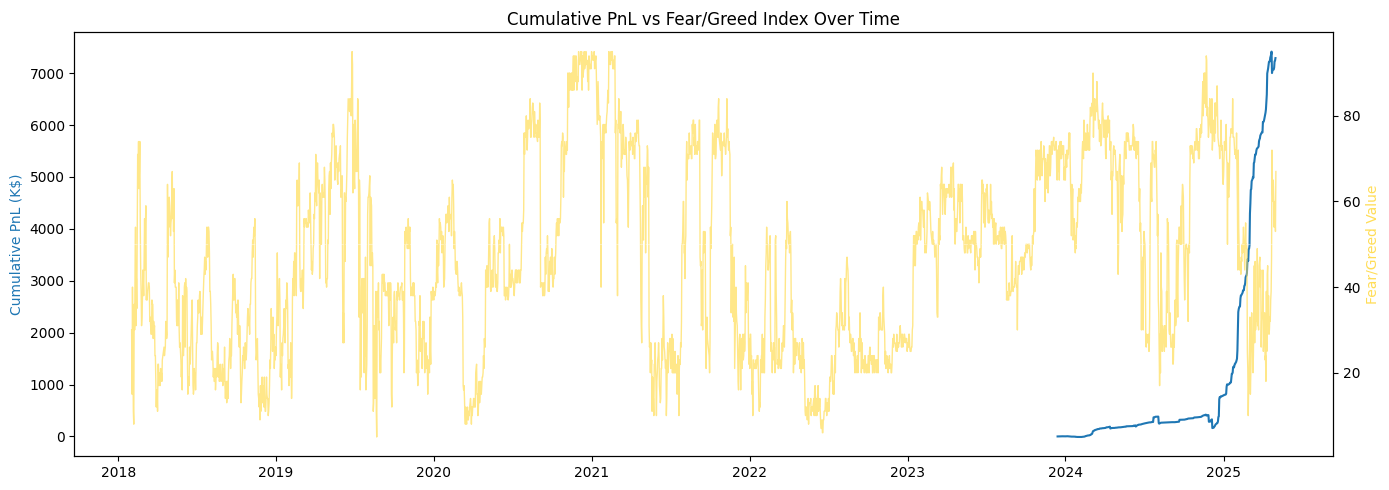

In [15]:
# Daily total PnL
daily_pnl = closed.groupby('date')['Closed PnL'].sum().cumsum() / 1e3

fig, ax1 = plt.subplots(figsize=(14, 5))

# Cumulative PnL
ax1.plot(daily_pnl.index, daily_pnl.values, color='#1f77b4', linewidth=1.5, label='Cumulative PnL')
ax1.set_ylabel('Cumulative PnL (K$)', color='#1f77b4')
ax1.set_title('Cumulative PnL vs Fear/Greed Index Over Time')

# Fear/Greed overlay
ax2 = ax1.twinx()
ax2.plot(fg['date'], fg['value'], color='#ffdd57', linewidth=1, alpha=0.7, label='Fear/Greed')
ax2.set_ylabel('Fear/Greed Value', color='#ffdd57')
ax2.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

## Key Findings & Trading Strategy Insights

### 1. Fear zones generate more PnL per trade
pretty straightforward honestly — traders made more money per trade
when the market was fearful vs when it was greedy.
Fear = $126/trade, Extreme Fear = $95/trade
Greed = $69/trade, Extreme Greed = $46/trade
the crowded greed market just doesn't have the same edges.

### 2. direction matters more than you think
shorts clearly outperformed in fear zones ($207 avg vs $83 for longs)
longs took over in greed ($88 avg vs $28 for shorts)
moral of the story — align your direction with the sentiment
or you're just fighting the market for no reason

### 3. HYPE and SOL were the real performers, not BTC/ETH
BTC and ETH finished 3rd and 4th in total PnL
HYPE ($1.95M) and SOL ($1.63M) ran the show
volatile assets = more opportunity for traders
blue chips are safer but the returns reflect that

### 4. Strategy Framework

| Sentiment      | Recommended Action                      |
|----------------|-----------------------------------------|
| Extreme Fear   | Short with conviction, size up          |
| Fear           | Best zone for short trades              |
| Neutral        | Reduce size, wait for clear signal      |
| Greed          | Lean long, start taking partial profits |
| Extreme Greed  | Close positions, avoid fresh entries    |

bottom line — sentiment is a legitimate edge if you actually use it.
most traders ignore it and wonder why they underperform.